In [45]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

In [46]:
## Data file
df = pd.read_csv('cleaned data.csv')

## 1) Train Test Split

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df['Package Range'])

In [49]:
x_train,x_test,y_train,y_test = train_test_split(df.drop(columns=['Package Range']),
                                                 y,
                                                 test_size=0.2,
                                                 random_state=42) 

## 2) Encoding

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder 

In [51]:
preprocessing = ColumnTransformer(
    transformers=[
        ('Degree program',OneHotEncoder(handle_unknown='ignore'),['Degree Program']),
        ('CGPA  Average',OrdinalEncoder(categories=[['Below 6.0','6.0 – 6.9','7.0 – 7.9','8.0 – 8.9','9.0+']]),['CGPA  Average']),
        ('Internship Experience',OrdinalEncoder(categories=[['Yes (paid)','Yes (unpaid)','No']]),['Internship Experience']),
        ('Number of Projects Completed',OrdinalEncoder(categories=[['0','1–2','3–4','5+']]),['Number of Projects Completed']),
        ('Certifications Completed',OrdinalEncoder(categories=[['0','1–2','3–4','5+']]),['Certifications Completed']),
        ('DSA / Syllabus Coverage',OrdinalEncoder(categories=[['DSA','Projects','Core subjects','Aptitude','Combination of all']]),['DSA / Syllabus Coverage']),
        ('Aptitude/ Syllabus Coverage',OrdinalEncoder(categories=[['DSA','Projects','Core subjects','Aptitude','Combination of all']]),['Aptitude/ Syllabus Coverage']),

    ],remainder='passthrough'
)

In [52]:
## import 
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, \
    confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve 

In [53]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

In [54]:
## Data file
df = pd.read_csv('cleaned data.csv')

## 1) Train Test Split

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df['Package Range'])

In [57]:
y

array([0, 3, 3, 3, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 3, 0, 3, 3, 3, 0, 2,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 3])

In [58]:
x_train,x_test,y_train,y_test = train_test_split(df.drop(columns=['Package Range']),
                                                 y,
                                                 test_size=0.3,
                                                 random_state=42) 

## 2) Encoding

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder 

In [60]:
preprocessing = ColumnTransformer(
    transformers=[
        ('Degree program',OneHotEncoder(handle_unknown='ignore'),['Degree Program']),
        ('CGPA  Average',OrdinalEncoder(categories=[['Below 6.0','6.0 – 6.9','7.0 – 7.9','8.0 – 8.9','9.0+']]),['CGPA  Average']),
        ('Internship Experience',OrdinalEncoder(categories=[['Yes (paid)','Yes (unpaid)','No']]),['Internship Experience']),
        ('Number of Projects Completed',OrdinalEncoder(categories=[['0','1–2','3–4','5+']]),['Number of Projects Completed']),
        ('Certifications Completed',OrdinalEncoder(categories=[['0','1–2','3–4','5+']]),['Certifications Completed']),
        ('DSA / Syllabus Coverage',OrdinalEncoder(categories=[['Basics only','Intermediate','Advanced','Not prepared']]),['DSA / Syllabus Coverage']),
        ('Aptitude/ Syllabus Coverage',OrdinalEncoder(categories=[['Basics only','Intermediate','Advanced','Not prepared']]),['Aptitude/ Syllabus Coverage']),

    ],remainder='passthrough'
)

## 3) Model Training

In [61]:
## import 
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score

In [62]:
models = {
    'Decision Tree':DecisionTreeClassifier(),
    'Random Forest':RandomForestClassifier()     
} 

for model_name, model in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessing),
        ('model', model)
    ])

    pipe.fit(x_train, y_train)

    y_train_pred = pipe.predict(x_train)
    y_test_pred = pipe.predict(x_test)

    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(
        y_train, y_train_pred,
        average='weighted',#Give more importance to classes having more samples.
        zero_division=0#This prevents errors or warnings.
    )
    model_train_recall = recall_score(
        y_train, y_train_pred,
        average='weighted',
        zero_division=0
    )

    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(
        y_test, y_test_pred,
        average='weighted',
        zero_division=0
    )
    model_test_recall = recall_score(
        y_test, y_test_pred,
        average='weighted',
        zero_division=0
    )

    print('-=>', model_name)

    print('Training Accuracy:', model_train_accuracy)
    print('Training F1:', model_train_f1)

    print('Testing Accuracy:', model_test_accuracy)
    print('Testing F1:', model_test_f1)

-=> Decision Tree
Training Accuracy: 1.0
Training F1: 1.0
Testing Accuracy: 1.0
Testing F1: 1.0
-=> Random Forest
Training Accuracy: 1.0
Training F1: 1.0
Testing Accuracy: 1.0
Testing F1: 1.0


## 4) Hyperparameter Tuning

In [83]:
rf_params = {
    'model__max_depth':[5,8,15,None,10],
    'model__max_features':[5,7,'auto',8],
    'model__min_samples_split':[2,8,15,20],
    'model__n_estimators':[100,200,500,1000]
}

In [84]:
# models list for hyperparameter tuning 
randomcv_models = [
    ('RF',RandomForestClassifier(),rf_params),
]

In [85]:
randomcv_models

[('RF',
  RandomForestClassifier(),
  {'model__max_depth': [5, 8, 15, None, 10],
   'model__max_features': [5, 7, 'auto', 8],
   'model__min_samples_split': [2, 8, 15, 20],
   'model__n_estimators': [100, 200, 500, 1000]})]

In [86]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    pipe = Pipeline([
        ('preprocessor',preprocessing),
        ('model',model)
    ])
    random = RandomizedSearchCV(estimator=pipe,
                                param_distributions=params,
                                n_iter=100,
                                cv=3,
                                verbose=2,
                                n_jobs=1) 
    random.fit(x_train,y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"--------------------best params for {model_name}------------------")
    print(model_param[model_name])


Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END model__max_depth=None, model__max_features=8, model__min_samples_split=15, model__n_estimators=200; total time=   0.8s
[CV] END model__max_depth=None, model__max_features=8, model__min_samples_split=15, model__n_estimators=200; total time=   0.8s
[CV] END model__max_depth=None, model__max_features=8, model__min_samples_split=15, model__n_estimators=200; total time=   2.4s
[CV] END model__max_depth=8, model__max_features=auto, model__min_samples_split=15, model__n_estimators=1000; total time=   0.2s
[CV] END model__max_depth=8, model__max_features=auto, model__min_samples_split=15, model__n_estimators=1000; total time=   0.1s
[CV] END model__max_depth=8, model__max_features=auto, model__min_samples_split=15, model__n_estimators=1000; total time=   0.0s
[CV] END model__max_depth=10, model__max_features=8, model__min_samples_split=15, model__n_estimators=200; total time=   2.1s
[CV] END model__max_depth=10, model__max

In [90]:
pipe = Pipeline([
    ('preprocessor', preprocessing),
    ('model', RandomForestClassifier(
        n_estimators=100,
        min_samples_split=2,
        max_features=5,
        max_depth=5
    ))
])

pipe.fit(x_train, y_train)

y_train_pred = pipe.predict(x_train)
y_test_pred = pipe.predict(x_test)
model_train_accuracy = accuracy_score(y_train, y_train_pred)
model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
model_train_precision = precision_score(
    y_train, y_train_pred,
    average='weighted',#Give more importance to classes having more samples.
    zero_division=0#This prevents errors or warnings.
)
model_train_recall = recall_score(
    y_train, y_train_pred,
    average='weighted',
    zero_division=0
)
model_test_accuracy = accuracy_score(y_test, y_test_pred)
model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
model_test_precision = precision_score(
    y_test, y_test_pred,
    average='weighted',
    zero_division=0
)
model_test_recall = recall_score(
    y_test, y_test_pred,
    average='weighted',
    zero_division=0
)
print('Training Accuracy:', model_train_accuracy)
print('Training F1:', model_train_f1)
print('Testing Accuracy:', model_test_accuracy)
print('Testing F1:', model_test_f1)

Training Accuracy: 1.0
Training F1: 1.0
Testing Accuracy: 1.0
Testing F1: 1.0


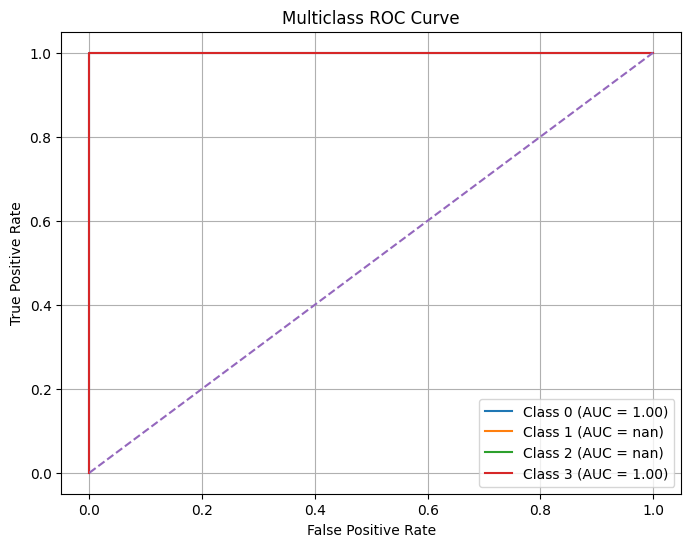

In [91]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Train pipeline
pipe = Pipeline([
    ('preprocessor', preprocessing),
    ('model', RandomForestClassifier(
        n_estimators=100,
        min_samples_split=2,
        max_features=5,
        max_depth=5,
        random_state=42
    ))
])

pipe.fit(x_train, y_train)

# Predicted probabilities
y_prob = pipe.predict_proba(x_test)

# Convert multiclass labels to binary format
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

# Plot ROC Curve for each class
plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {classes[i]} (AUC = {roc_auc:.2f})'
    )

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [92]:
from joblib import dump


dump(pipe, 'placement_model.joblib')

['placement_model.joblib']